In [33]:
import numpy as np
import pandas as pd

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

print('Train data shape: ', train_data.shape)
print('Test data shape: ', test_data.shape)

train_data.head()

Train data shape:  (891, 12)
Test data shape:  (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [35]:
train_data.info()
print()
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass 

In [36]:
train_data.pivot_table(index="Pclass",values='Survived').reset_index()


,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [37]:
df_test = train_data[["Pclass", "Survived"]]
df_test.groupby(["Pclass"],as_index=False).mean()
##Same as above 

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [38]:
train_data.pivot_table(index="Sex",values='Survived').reset_index()

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [39]:
train_data.pivot_table(index="Embarked",values='Survived').reset_index()

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.336957


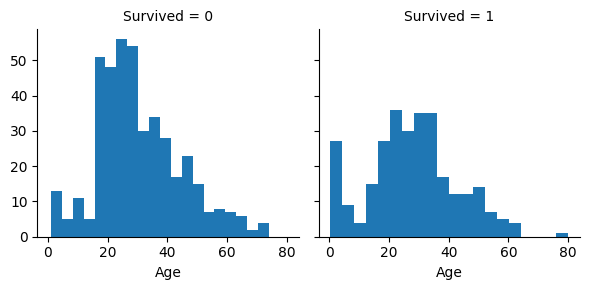

In [40]:
# Plot survival per Age bin
g = sns.FacetGrid(train_data, col='Survived')
g.map(plt.hist, 'Age', bins=20)
plt.show()


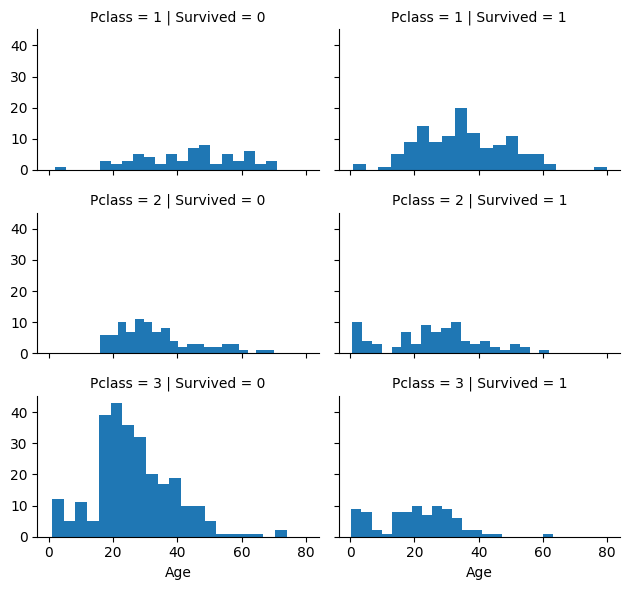

In [41]:
g = sns.FacetGrid(train_data, col='Survived', row='Pclass', height=2, aspect=1.6)
g.map(plt.hist, 'Age', bins=20)
plt.show()

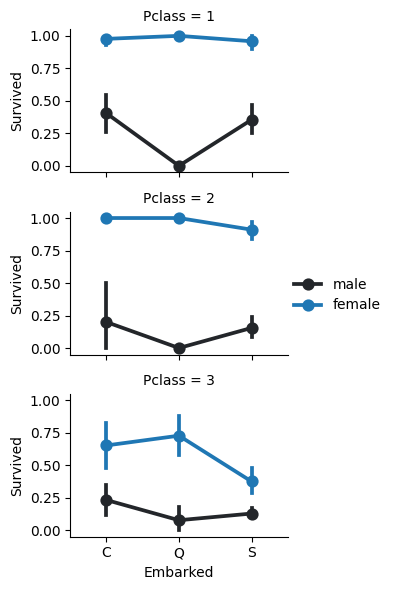

In [42]:
g = sns.FacetGrid(train_data, row='Pclass', height=2, aspect=1.6)
g.map(sns.pointplot, 'Embarked', 'Survived', 'Sex', hue_order=['male', 'female'], order=['C', 'Q', 'S'])
g.add_legend()
plt.show()

In [43]:
train_data['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

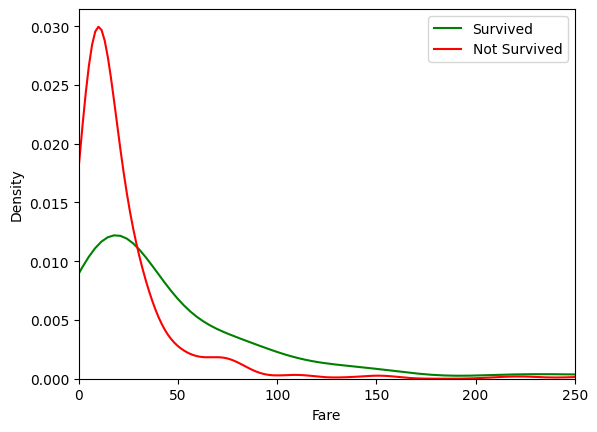

In [44]:
sns.kdeplot(train_data['Fare'][train_data.Survived == 1], color="green")
sns.kdeplot(train_data['Fare'][train_data.Survived == 0], color="red")
plt.legend(['Survived', 'Not Survived'])
plt.xlim(0, 250) # Remove the tail
plt.show()

In [45]:
train_data[train_data['Fare'] <= 20]['Pclass'].value_counts()

Pclass
3    405
2    104
1      6
Name: count, dtype: int64

In [46]:
train_data[['Fare', 'Pclass']].corr()


,Fare,Pclass
Fare,1.0000,-0.5495
Pclass,-0.5495,1.0000


In [47]:
# Lets investigate fares=0
train_data[train_data['Fare'] == 0]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
179,180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,NaN,S
263,264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,B94,S
271,272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0,NaN,S
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,239853,0.0,NaN,S
466,467,0,2,"Campbell, Mr. William",male,NaN,0,0,239853,0.0,NaN,S
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0,NaN,S
597,598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,NaN,S
633,634,0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0,NaN,S


In [48]:
train_data['Cabin'].value_counts(dropna=False, normalize=True)

Cabin
NaN            0.771044
G6             0.004489
C23 C25 C27    0.004489
B96 B98        0.004489
F2             0.003367
                 ...   
E17            0.001122
A24            0.001122
C50            0.001122
B42            0.001122
C148           0.001122
Name: proportion, Length: 148, dtype: float64

In [49]:
#Data Cleaning / Feature Engineering

In [50]:
def merge_datasets(train, test):
    columns_to_keep = ['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Cabin', 'Fare', 'Embarked']
    columns_to_keep.extend(['Survived', 'is_train'])
    
    test['Survived'] = None
    train['is_train'] = True
    test['is_train'] = False
    
    combined_df = pd.concat([train[columns_to_keep], test[columns_to_keep]])
    combined_df['Survived'] = combined_df['Survived'].astype(float)
    
    return combined_df

combined = merge_datasets(train_data, test_data)
combined.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Cabin,Fare,Embarked,Survived,is_train
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,NaN,7.2500,S,0.0,True
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,C85,71.2833,C,1.0,True
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,NaN,7.9250,S,1.0,True
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,C123,53.1000,S,1.0,True
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,NaN,8.0500,S,0.0,True


In [51]:
#Handle Missing values

In [52]:
# !pip3 install regex
import regex as re

titles_mapping = {
        "Mr" :         "Mr",
        "Capt":        "Mr",
        "Col":         "Mr",
        "Major":       "Mr",
        "Dr":          "Mr",
        "Rev":         "Mr",
        "Jonkheer":    "Mr",
        "Don":         "Mr",
        "Sir" :        "Mr",
        "Mme":         "Mrs",
        "Mrs" :        "Mrs",
        "Countess":    "Mrs",
        "Dona":        "Mrs",
        "Lady" :       "Mrs",
        "Master" :     "Master", # Master means boy child here
        "Ms":          "Miss",
        "Mlle":        "Miss",
        "Miss" :       "Miss",
    }

def find_title_family(name):
    p = re.compile(' ([A-Za-z]+)\.')
    title = p.search(name).group(1)
    return titles_mapping[title]

In [53]:
def fill_missing(combined):
    df = combined.copy()
    
    df['Embarked'] = df['Embarked'].fillna('S')
    
    df['Cabin'] = df['Cabin'].fillna('X')
    
    df['title'] = df['Name'].apply(find_title_family)
    
    age_group = df.groupby(['Pclass', 'title'])['Age'].mean().reset_index()
    
    def fill_age(x):
        return age_group[(age_group['Pclass'] == x['Pclass']) & 
                         (age_group['title'] == x['title'])]['Age'].values[0]
    
    df['Age'] = df.apply(lambda x: fill_age(x) if np.isnan(x['Age']) else x['Age'], axis=1)
    
    df['Fare'] = df['Fare'].fillna(df[df['Pclass'] == 3]['Fare'].median()) # There is 1 passenger without Fare
    
    return df
    
combined_filled = fill_missing(combined)

In [54]:
#Create new features
# Extract deck out of Cabin column
combined_filled['deck'] = combined_filled['Cabin'].str.slice(0, 1)

# Extract Title out of Name column
combined_filled['title'] = combined_filled['Name'].apply(find_title_family)
combined_filled['surname'] = combined_filled['Name'].apply(lambda x: x.split(',')[0])

# Group Features
combined_filled['family_size'] = combined_filled['SibSp'] + combined_filled['Parch'] + 1

# People with the same fare are most likely to have bougth their tickets together
combined_filled['ticket_freq'] = combined_filled['Ticket'].map(combined_filled['Ticket'].value_counts())
combined_filled['fare_freq'] = combined_filled['Fare'].map(combined_filled['Fare'].value_counts())

combined_filled['is_large_family'] = combined_filled['family_size'] > 4

# Create has_fare feature
combined_filled['has_fare'] = combined_filled['Fare'] != 0

# Compute real fare
combined_filled['fare_per_ticket'] = combined_filled['Fare'] / combined_filled['ticket_freq']

# Create Fare bands
combined_filled['fare_band'] = pd.qcut(combined_filled['fare_per_ticket'], 5, labels=[0, 1, 2, 3, 4])

# Create Age bands
def find_age_band(age):
    if age < 14:
        return 0
    elif age <= 30:
        return 2
    elif age <= 64:
        return 1
    else: 
        return 3

combined_filled['age_band'] = combined_filled['Age'].apply(find_age_band)
combined_filled['is_minor'] = combined_filled['age_band'] == 0

combined_filled['embarked_C'] = combined_filled['Embarked'].apply(lambda x: 1 if x == 'C' else 0)

combined_filled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Pclass           1309 non-null   int64   
 1   Name             1309 non-null   object  
 2   Sex              1309 non-null   object  
 3   Age              1309 non-null   float64 
 4   SibSp            1309 non-null   int64   
 5   Parch            1309 non-null   int64   
 6   Ticket           1309 non-null   object  
 7   Cabin            1309 non-null   object  
 8   Fare             1309 non-null   float64 
 9   Embarked         1309 non-null   object  
 10  Survived         891 non-null    float64 
 11  is_train         1309 non-null   bool    
 12  title            1309 non-null   object  
 13  deck             1309 non-null   object  
 14  surname          1309 non-null   object  
 15  family_size      1309 non-null   int64   
 16  ticket_freq      1309 non-null   int64   
 17  f

In [57]:
combined_filled['ticket_formatted'] = combined_filled['Embarked'] \
    + '-' + combined_filled['Ticket'].astype(str).str.slice_replace(-2, repl='XX') \
    + '-' + combined_filled['Fare'].astype(str)

combined_filled['group_id'] = combined_filled['surname'] \
    + '-' + combined_filled['Pclass'].astype(str) \
    + '-' + combined_filled['ticket_formatted']

combined_filled['group_id'] = combined_filled.apply(
    lambda x: 'no_group' if x['title'] == 'Mr' else x['group_id'], axis=1)

combined_filled['group_freq'] = combined_filled['group_id'].map(combined_filled['group_id'].value_counts())

combined_filled['group_id'] = combined_filled.apply(
    lambda x: 'no_group' if x['group_freq'] <= 1 else x['group_id'], axis=1)

# Add nanies and relatives
group = combined_filled[combined_filled['group_id'] != 'no_group']
for i, row in combined_filled.iterrows():
    if (row['title'] != 'Mr') & (row['group_id'] == 'no_group'):
        if group[group['ticket_formatted'] == row['ticket_formatted']].shape[0] > 0:
            combined_filled.at[i, 'group_id'] = group[group['ticket_formatted'] == row['ticket_formatted']].iloc[0]['group_id']

combined_filled['group_freq'] = combined_filled['group_id'].map(combined_filled['group_id'].value_counts())

combined_filled['group_survival'] = combined_filled['group_id'].map(
    combined_filled[combined_filled['is_train']].groupby('group_id')['Survived'].mean()
)


survival_rates_sex_class = (
    combined_filled[
        (combined_filled['is_train']) & 
        (combined_filled['group_id'] == 'no_group')
    ]
    .groupby(['Pclass', 'Sex'])['Survived']
    .mean()
    .reset_index()
)


# Set group survival rate according to average survival rate for alone people of same Sex and Pclass
combined_filled['group_survival'] = combined_filled.apply(
    lambda x: combined_filled[
        (combined_filled['is_train'] == True) &
        (combined_filled['group_id'] == 'no_group') &
        (combined_filled['Pclass'] == x['Pclass']) &
        (combined_filled['Sex'] == x['Sex'])
    ]['Survived'].mean() if x['group_id'] == 'no_group' else x['group_survival'],
    axis=1
)


def set_survival_na(x):
    if pd.isna(x['group_survival']):
        return combined_filled[combined_filled['group_freq'] == x['group_freq']]['group_survival'].mean()
    else:
        return x['group_survival']


# For NaN, set to average survival rate for group of some frequency
combined_filled['group_survival'] = combined_filled.apply(set_survival_na, axis=1)



In [58]:
from sklearn.preprocessing import minmax_scale, StandardScaler

def dummy_encoding(df, feature):
    dummies = pd.get_dummies(df[feature], prefix=feature, drop_first=True)
    df = pd.concat([df,dummies],axis=1)
    df = df.drop(feature, axis=1)
    return df

def prepare_features(df, features):
    """Make the feature usable by an ML algorithm"""
    df = df.copy()
    
    for col in df.columns:
        if col not in features['nominal'] + features['ordinal'] \
            + features['boolean'] + features['numeric'] + ['is_train', 'Survived']:
            df = df.drop(col, axis=1)
    
    # Transform useful features
    for feature in features['nominal']:
        df[feature] = df[feature].astype('category')
        df = dummy_encoding(df, feature)
    
    for feature in features['ordinal'] + features['boolean']:
        df[feature] = df[feature].astype('int')
    
    for feature in features['ordinal'] + features['numeric']:
        scaler = StandardScaler()
        df[[feature]] = scaler.fit_transform(df[[feature]])
        df[feature + '_scaled'] = df[feature]
        df = df.drop(feature, axis=1)
    
    return df
    
# Define type of each feature
features = {
    'nominal': ['Sex'], # sex*pclass, 'title'
    'ordinal': ['Pclass', 'fare_band'], # 'age_band'
    'boolean': ['is_minor'], # 'embarked_C', 'is_large_family', 'has_fare', 'is_minor'
    'numeric': ['group_survival'], # ['fare_per_ticket', 'Age']
}
combined_prepared = prepare_features(combined_filled, features)
combined_prepared.head()


,Survived,is_train,is_minor,Sex_male,Pclass_scaled,fare_band_scaled,group_survival_scaled
0,0.0,True,0,True,0.841916,-0.656806,-0.779636
1,1.0,True,0,False,-1.546098,1.455624,1.657344
2,1.0,True,0,False,0.841916,0.047337,0.304792
3,1.0,True,0,False,-1.546098,1.455624,1.657344
4,0.0,True,0,True,0.841916,0.047337,-0.779636


In [59]:
X_train = combined_prepared[combined_prepared['is_train'] == 1].drop(['Survived', 'is_train'], axis=1)
y_train = combined_prepared[combined_prepared['is_train'] == 1]['Survived'].astype(int)

X_test = combined_prepared[combined_prepared['is_train'] == 0].drop(['Survived', 'is_train'], axis=1)

In [60]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    random_state=2,
    n_estimators=25,
    min_samples_split=20,
    oob_score=True)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

results = pd.DataFrame({
    "PassengerId": test_data['PassengerId'],
    "Survived": predictions
})

results.to_csv('submission.csv', index=False)

print('Submission file has been exported.')
results.head()

Submission file has been exported.


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
